# References

https://www.ejtech.io/learn/train-yolo-models

https://www.ejtech.io/learn/yolo-on-raspberry-pi

https://docs.ultralytics.com/modes/train/#key-features-of-train-mode

# Preparation

## 1. Load

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

!rm -f /content/satellite_data.zip
!cp /content/gdrive/MyDrive/CS437/Project/satellite_data.zip /content

Mounted at /content/gdrive


## 2. Unzip

In [ ]:
!rm -rf /content/custom_data
!unzip -q /content/satellite_data.zip -d /content/custom_data

## 3. Install

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 21.7 MB/s eta 0:00:00


## 4. Configure
https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/coco128.yaml

In [ ]:
# Python function to automatically create data.yaml config file
# 1. Reads "classes.txt" file to get list of class names
# 2. Creates data dictionary with correct paths to folders, number of classes, and names of classes
# 3. Writes data in YAML format to data.yaml

import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read class.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! Please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data.yaml

Created config file at /content/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 1
names:
- satellite


# Split

In [ ]:
!rm -rf /content/data

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py

!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

# Split between train and val folders
# from pathlib import Path
# import random
# import os
# import sys
# import shutil
# import argparse

# data_path = "/content/custom_data"
# num_distinct_images = 110
# num_augmentation = 3
# train_percent = 0.9


# # Check for valid entries
# if not os.path.isdir(data_path):
#    print('Directory specified by --datapath not found. Verify the path is correct (and uses double back slashes if on Windows) and try again.')
#    sys.exit(0)
# if train_percent < .01 or train_percent > 0.99:
#    print('Invalid entry for train_pct. Please enter a number between .01 and .99.')
#    sys.exit(0)
# val_percent = 1 - train_percent

# # Define path to input dataset
# input_image_path = os.path.join(data_path,'images')
# input_label_path = os.path.join(data_path,'labels')

# # Define paths to image and annotation folders
# cwd = os.getcwd()
# train_img_path = os.path.join(cwd,'data/train/images')
# train_txt_path = os.path.join(cwd,'data/train/labels')
# val_img_path = os.path.join(cwd,'data/validation/images')
# val_txt_path = os.path.join(cwd,'data/validation/labels')

# # Create folders if they don't already exist
# for dir_path in [train_img_path, train_txt_path, val_img_path, val_txt_path]:
#    if not os.path.exists(dir_path):
#       os.makedirs(dir_path)
#       print(f'Created folder at {dir_path}.')

# # # Get list of all images and annotation files
# # img_file_list = [path for path in Path(input_image_path).rglob('*')]
# # txt_file_list = [path for path in Path(input_label_path).rglob('*')]

# # print(f'Number of image files: {len(img_file_list)}')
# # print(f'Number of annotation files: {len(txt_file_list)}')

# # Determine number of files to move to each folder
# train_num = int(num_distinct_images*train_percent)
# val_num = num_distinct_images - train_num
# print('Images moving to train: %d' % train_num)
# print('Images moving to validation: %d' % val_num)

# def move_to_val(img_fn, txt_fn):
#     if os.path.exists(os.path.join(input_image_path, img_fn)):
#         shutil.copy(os.path.join(input_image_path, img_fn), os.path.join(val_img_path, img_fn))
#     if os.path.exists(os.path.join(input_label_path, txt_fn)):
#         shutil.copy(os.path.join(input_label_path, txt_fn), os.path.join(val_txt_path, txt_fn))

# def move_to_train(img_fn, txt_fn):
#     if os.path.exists(os.path.join(input_image_path, img_fn)):
#         shutil.copy(os.path.join(input_image_path, img_fn), os.path.join(train_img_path, img_fn))
#     if os.path.exists(os.path.join(input_label_path, txt_fn)):
#         shutil.copy(os.path.join(input_label_path, txt_fn), os.path.join(train_txt_path, txt_fn))

# # select files randomly and copy them to train folder
# img_nums = [i for i in range(num_distinct_images)]
# while train_num > 0:
#   selected_num = random.choice(img_nums)
#   img_num = str(selected_num+1)
#   img_fn = img_num + '.jpg'
#   txt_fn = img_num + '.txt'
#   move_to_train(img_fn, txt_fn)

#   for i in range(1, num_augmentation+1):
#     img_fn = img_num + f"_aug_{i}.jpg"
#     txt_fn = img_num + f"_aug_{i}.txt"
#     move_to_train(img_fn, txt_fn)
#   img_nums.remove(selected_num)
#   train_num -= 1

# # move the rest to val folder
# print("val: ", img_nums)
# for img_num in img_nums:
#   img_num = str(img_num+1)

#   img_fn = img_num + '.jpg'
#   txt_fn = img_num + '.txt'
#   move_to_val(img_fn, txt_fn)

#   for i in range(1, num_augmentation+1):
#     img_fn = img_num + f"_aug_{i}.jpg"
#     txt_fn = img_num + f"_aug_{i}.txt"
#     move_to_val(img_fn, txt_fn)

--2025-12-09 15:54:10--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2025-12-09 15:54:10 (33.7 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 417
Number of annotation files: 416
Images moving to train: 375
Images moving to validation: 42


# Train

https://www.ejtech.io/learn/train-yolo-models

In [ ]:
!rm -rf /content/runs

In [ ]:
!yolo detect train data=/content/data.yaml model=yolo11s.pt epochs=40 imgsz=1200

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, ko

# Test

Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/42 /content/data/validation/images/1.jpg: 448x640 1 satellite, 53.9ms
image 2/42 /content/data/validation/images/10.jpg: 448x640 3 satellites, 12.0ms
image 3/42 /content/data/validation/images/101_aug_1.jpg: 416x640 11 satellites, 53.3ms
image 4/42 /content/data/validation/images/104_aug_2.jpg: 416x640 36 satellites, 12.0ms
image 5/42 /content/data/validation/images/108_aug_3.jpg: 416x640 1 satellite, 11.9ms
image 6/42 /content/data/validation/images/10_aug_1.jpg: 416x640 1 satellite, 11.9ms
image 7/42 /content/data/validation/images/11.jpg: 640x480 1 satellite, 51.4ms
image 8/42 /content/data/validation/images/19.jpg: 448x640 11 satellites, 12.8ms
image 9/42 /content/data/validation/images/19_aug_1.jpg: 448x640 8 satellites, 12.0ms
image 10/42 /content/data/validation/images/22_aug_2.jpg: 320x640 1 satellite, 56

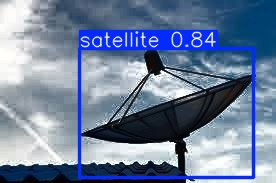

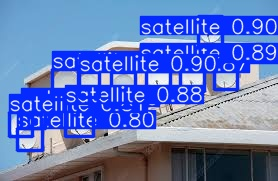

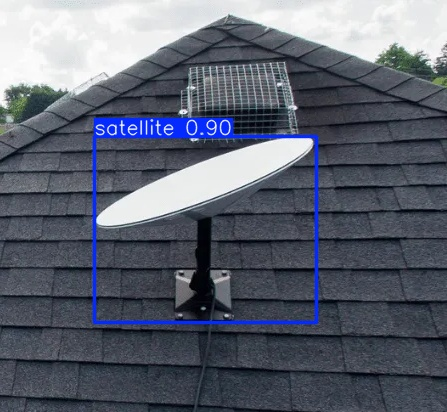

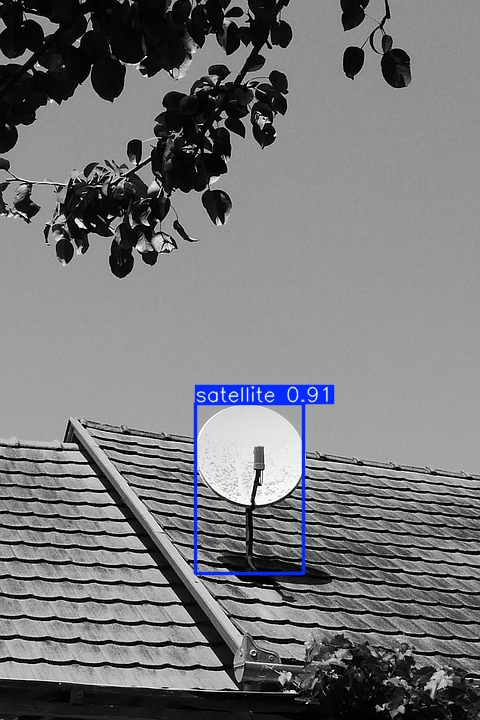

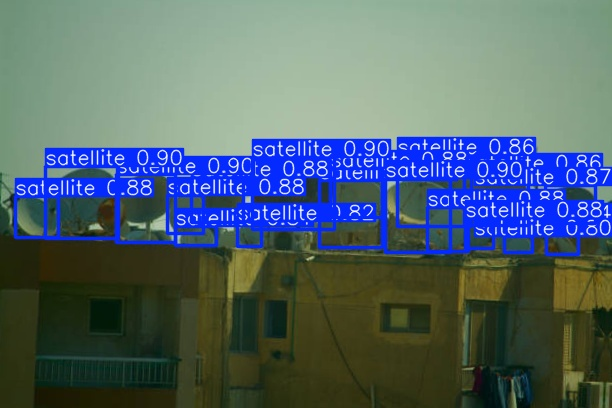

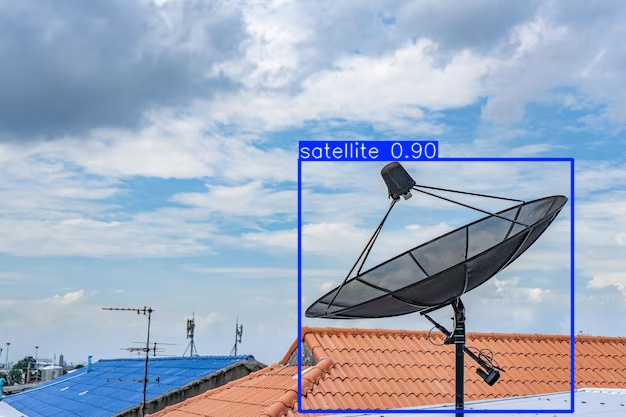

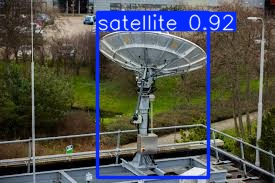

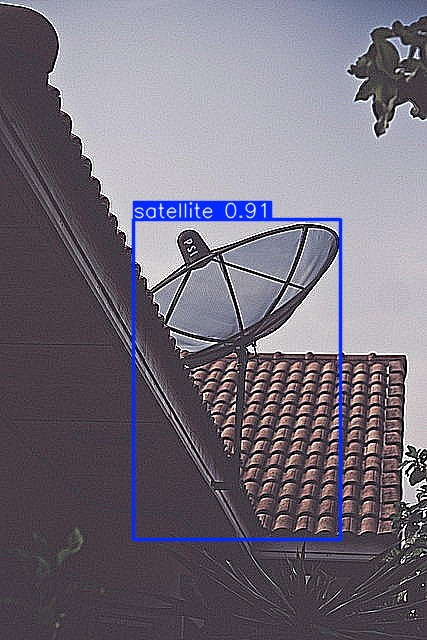

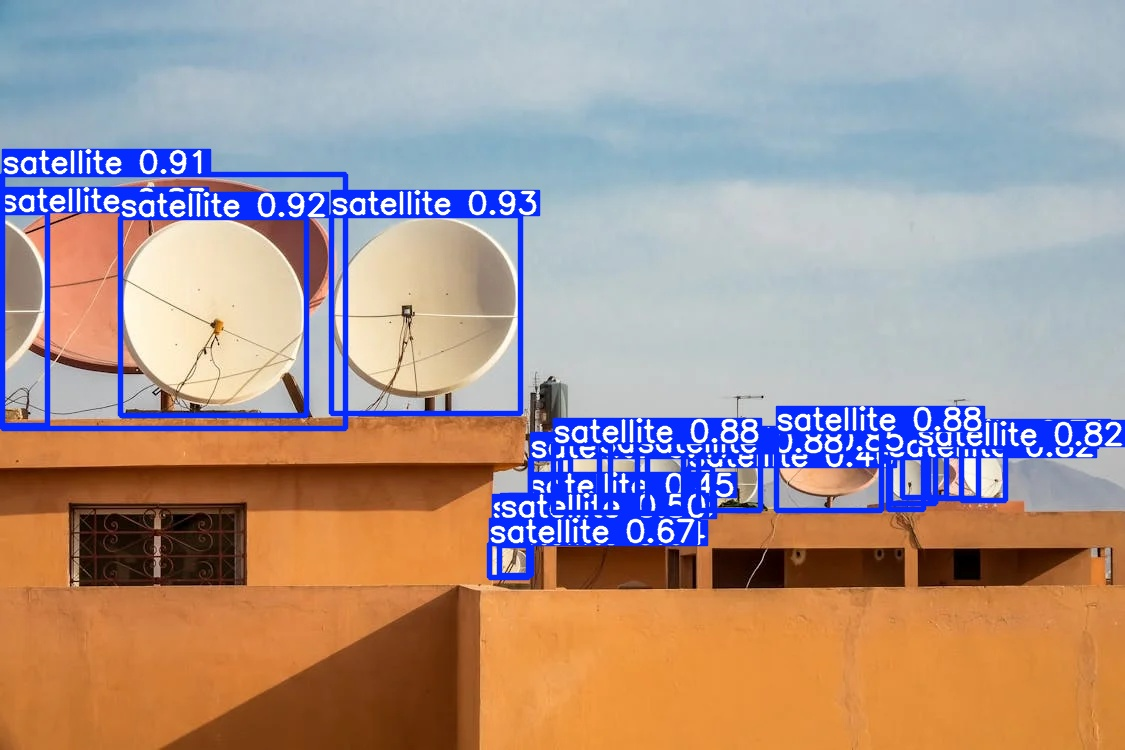

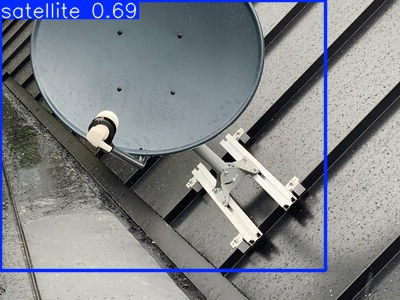

In [ ]:
!yolo detect predict model=runs/detect/train/weights/best.pt source=data/validation/images save=True

import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

# Download

In [ ]:
!rm -rf /content/my_model

In [ ]:
# # Create "my_model" folder to store model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/last.pt /content/my_model/last_model.pt
!cp /content/runs/detect/train/weights/best.pt /content/my_model/best_model.pt
!cp -r /content/runs/detect/train /content/my_model/train
!cp -r /content/runs/detect/predict /content/my_model/predict
!rm -rf /content/my_model/train/weights

# # Zip into "my_model.zip"
# %cd my_model
# !zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip my_model
# %cd /content
# !zip -r runs.zip /content/runs

cp: cannot stat '/content/runs/detect/train/weights/last.pt': No such file or directory
cp: cannot stat '/content/runs/detect/train/weights/best.pt': No such file or directory
cp: cannot stat '/content/runs/detect/train': No such file or directory
cp: cannot stat '/content/runs/detect/predict': No such file or directory
  adding: my_model/ (stored 0%)


In [ ]:
# This takes forever for some reason, you can also just download the model from the sidebar
from google.colab import files

files.download('/content/my_model.zip')
# files.download('/content/runs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Deploy

https://github.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/blob/main/yolo_detect.py

In [ ]:
import os
import sys
import argparse
import glob
import time

import cv2
import numpy as np
from ultralytics import YOLO

# Define and parse user input arguments

# parser = argparse.ArgumentParser()
# parser.add_argument('--model', help='Path to YOLO model file (example: "runs/detect/train/weights/best.pt")',
#                     required=True)
# parser.add_argument('--source', help='Image source, can be image file ("test.jpg"), \
#                     image folder ("test_dir"), video file ("testvid.mp4"), index of USB camera ("usb0"), or index of Picamera ("picamera0")',
#                     required=True)
# parser.add_argument('--thresh', help='Minimum confidence threshold for displaying detected objects (example: "0.4")',
#                     default=0.5)
# parser.add_argument('--resolution', help='Resolution in WxH to display inference results at (example: "640x480"), \
#                     otherwise, match source resolution',
#                     default=None)
# parser.add_argument('--record', help='Record results from video or webcam and save it as "demo1.avi". Must specify --resolution argument to record.',
#                     action='store_true')

# args = parser.parse_args()


# Parse user inputs
model_path = args.model
img_source = args.source
min_thresh = args.thresh
user_res = args.resolution
record = args.record

# Check if model file exists and is valid
if (not os.path.exists(model_path)):
    print('ERROR: Model path is invalid or model was not found. Make sure the model filename was entered correctly.')
    sys.exit(0)

# Load the model into memory and get labemap
model = YOLO(model_path, task='detect')
labels = model.names

# Parse input to determine if image source is a file, folder, video, or USB camera
img_ext_list = ['.jpg','.JPG','.jpeg','.JPEG','.png','.PNG','.bmp','.BMP']
vid_ext_list = ['.avi','.mov','.mp4','.mkv','.wmv']

if os.path.isdir(img_source):
    source_type = 'folder'
elif os.path.isfile(img_source):
    _, ext = os.path.splitext(img_source)
    if ext in img_ext_list:
        source_type = 'image'
    elif ext in vid_ext_list:
        source_type = 'video'
    else:
        print(f'File extension {ext} is not supported.')
        sys.exit(0)
elif 'usb' in img_source:
    source_type = 'usb'
    usb_idx = int(img_source[3:])
elif 'picamera' in img_source:
    source_type = 'picamera'
    picam_idx = int(img_source[8:])
else:
    print(f'Input {img_source} is invalid. Please try again.')
    sys.exit(0)

# Parse user-specified display resolution
resize = False
if user_res:
    resize = True
    resW, resH = int(user_res.split('x')[0]), int(user_res.split('x')[1])

# Check if recording is valid and set up recording
if record:
    if source_type not in ['video','usb']:
        print('Recording only works for video and camera sources. Please try again.')
        sys.exit(0)
    if not user_res:
        print('Please specify resolution to record video at.')
        sys.exit(0)

    # Set up recording
    record_name = 'demo1.avi'
    record_fps = 30
    recorder = cv2.VideoWriter(record_name, cv2.VideoWriter_fourcc(*'MJPG'), record_fps, (resW,resH))

# Load or initialize image source
if source_type == 'image':
    imgs_list = [img_source]
elif source_type == 'folder':
    imgs_list = []
    filelist = glob.glob(img_source + '/*')
    for file in filelist:
        _, file_ext = os.path.splitext(file)
        if file_ext in img_ext_list:
            imgs_list.append(file)
elif source_type == 'video' or source_type == 'usb':

    if source_type == 'video': cap_arg = img_source
    elif source_type == 'usb': cap_arg = usb_idx
    cap = cv2.VideoCapture(cap_arg)

    # Set camera or video resolution if specified by user
    if user_res:
        ret = cap.set(3, resW)
        ret = cap.set(4, resH)

elif source_type == 'picamera':
    from picamera2 import Picamera2
    cap = Picamera2()
    cap.configure(cap.create_video_configuration(main={"format": 'RGB888', "size": (resW, resH)}))
    cap.start()

# Set bounding box colors (using the Tableu 10 color scheme)
bbox_colors = [(164,120,87), (68,148,228), (93,97,209), (178,182,133), (88,159,106),
              (96,202,231), (159,124,168), (169,162,241), (98,118,150), (172,176,184)]

# Initialize control and status variables
avg_frame_rate = 0
frame_rate_buffer = []
fps_avg_len = 200
img_count = 0

# Begin inference loop
while True:

    t_start = time.perf_counter()

    # Load frame from image source
    if source_type == 'image' or source_type == 'folder': # If source is image or image folder, load the image using its filename
        if img_count >= len(imgs_list):
            print('All images have been processed. Exiting program.')
            sys.exit(0)
        img_filename = imgs_list[img_count]
        frame = cv2.imread(img_filename)
        img_count = img_count + 1

    elif source_type == 'video': # If source is a video, load next frame from video file
        ret, frame = cap.read()
        if not ret:
            print('Reached end of the video file. Exiting program.')
            break

    elif source_type == 'usb': # If source is a USB camera, grab frame from camera
        ret, frame = cap.read()
        if (frame is None) or (not ret):
            print('Unable to read frames from the camera. This indicates the camera is disconnected or not working. Exiting program.')
            break

    elif source_type == 'picamera': # If source is a Picamera, grab frames using picamera interface
        frame = cap.capture_array()
        if (frame is None):
            print('Unable to read frames from the Picamera. This indicates the camera is disconnected or not working. Exiting program.')
            break

    # Resize frame to desired display resolution
    if resize == True:
        frame = cv2.resize(frame,(resW,resH))

    # Run inference on frame
    results = model(frame, verbose=False)

    # Extract results
    detections = results[0].boxes

    # Initialize variable for basic object counting example
    object_count = 0

    # Go through each detection and get bbox coords, confidence, and class
    for i in range(len(detections)):

        # Get bounding box coordinates
        # Ultralytics returns results in Tensor format, which have to be converted to a regular Python array
        xyxy_tensor = detections[i].xyxy.cpu() # Detections in Tensor format in CPU memory
        xyxy = xyxy_tensor.numpy().squeeze() # Convert tensors to Numpy array
        xmin, ymin, xmax, ymax = xyxy.astype(int) # Extract individual coordinates and convert to int

        # Get bounding box class ID and name
        classidx = int(detections[i].cls.item())
        classname = labels[classidx]

        # Get bounding box confidence
        conf = detections[i].conf.item()

        # Draw box if confidence threshold is high enough
        if conf > 0.5:

            color = bbox_colors[classidx % 10]
            cv2.rectangle(frame, (xmin,ymin), (xmax,ymax), color, 2)

            label = f'{classname}: {int(conf*100)}%'
            labelSize, baseLine = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1) # Get font size
            label_ymin = max(ymin, labelSize[1] + 10) # Make sure not to draw label too close to top of window
            cv2.rectangle(frame, (xmin, label_ymin-labelSize[1]-10), (xmin+labelSize[0], label_ymin+baseLine-10), color, cv2.FILLED) # Draw white box to put label text in
            cv2.putText(frame, label, (xmin, label_ymin-7), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1) # Draw label text

            # Basic example: count the number of objects in the image
            object_count = object_count + 1

    # Calculate and draw framerate (if using video, USB, or Picamera source)
    if source_type == 'video' or source_type == 'usb' or source_type == 'picamera':
        cv2.putText(frame, f'FPS: {avg_frame_rate:0.2f}', (10,20), cv2.FONT_HERSHEY_SIMPLEX, .7, (0,255,255), 2) # Draw framerate

    # Display detection results
    cv2.putText(frame, f'Number of objects: {object_count}', (10,40), cv2.FONT_HERSHEY_SIMPLEX, .7, (0,255,255), 2) # Draw total number of detected objects
    cv2.imshow('YOLO detection results',frame) # Display image
    if record: recorder.write(frame)

    # If inferencing on individual images, wait for user keypress before moving to next image. Otherwise, wait 5ms before moving to next frame.
    if source_type == 'image' or source_type == 'folder':
        key = cv2.waitKey()
    elif source_type == 'video' or source_type == 'usb' or source_type == 'picamera':
        key = cv2.waitKey(5)

    if key == ord('q') or key == ord('Q'): # Press 'q' to quit
        break
    elif key == ord('s') or key == ord('S'): # Press 's' to pause inference
        cv2.waitKey()
    elif key == ord('p') or key == ord('P'): # Press 'p' to save a picture of results on this frame
        cv2.imwrite('capture.png',frame)

    # Calculate FPS for this frame
    t_stop = time.perf_counter()
    frame_rate_calc = float(1/(t_stop - t_start))

    # Append FPS result to frame_rate_buffer (for finding average FPS over multiple frames)
    if len(frame_rate_buffer) >= fps_avg_len:
        temp = frame_rate_buffer.pop(0)
        frame_rate_buffer.append(frame_rate_calc)
    else:
        frame_rate_buffer.append(frame_rate_calc)

    # Calculate average FPS for past frames
    avg_frame_rate = np.mean(frame_rate_buffer)


# Clean up
print(f'Average pipeline FPS: {avg_frame_rate:.2f}')
if source_type == 'video' or source_type == 'usb':
    cap.release()
elif source_type == 'picamera':
    cap.stop()
if record: recorder.release()
cv2.destroyAllWindows()

In [ ]:
conda create --name yolo-env1 python=3.12 -y
conda activate yolo-env1

pip install ultralytics

pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

cd path/to/folder

curl -o yolo_detect.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-Models/refs/heads/main/yolo_detect.py

python yolo_detect.py --model my_model.pt --source usb0 --resolution 1280x720

# run on raspberry pi
yolo export model=my_model.pt format=ncnn
python yolo_detect.py --model=yolo11n_ncnn_model --source=usb0 --resolution=640x480